NAB series: 22695 samples, labelled windows: 4
Anomaly-free runs (start, end): [(0, 1838), (2981, 3415), (4558, 10149), (10149, 15769), (16912, 18944), (20087, 22695)]
Config: 10 seeds, 60 epochs
Model sizes: AE 674, VAE 1232 parameters

Filter properties (white-noise power passed, impulse peak kept, delay)
 cutoff  order  noise_power_causal  noise_power_zerophase  impulse_peak_causal  impulse_peak_zerophase  delay_samples_causal
   0.02      4              0.0410                 0.0359               0.0479                  0.0410                    23
   0.05      4              0.1024                 0.0899               0.1193                  0.1024                     9
   0.10      4              0.2038                 0.1803               0.2335                  0.2038                     5
   0.20      4              0.4022                 0.3651               0.4220                  0.4022                     2
   0.05      2              0.1097                 0.0833         

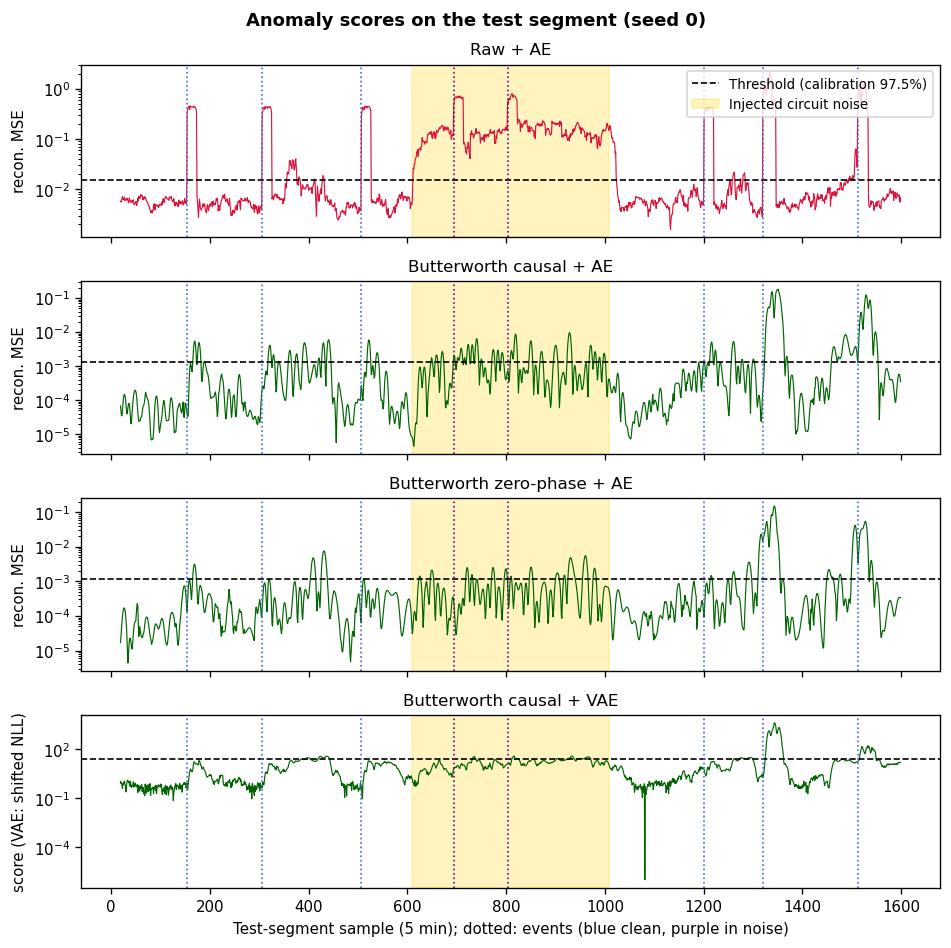

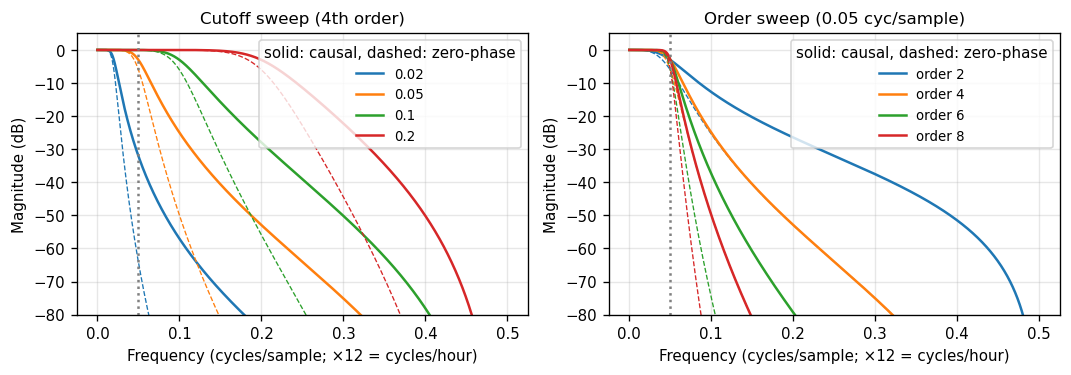

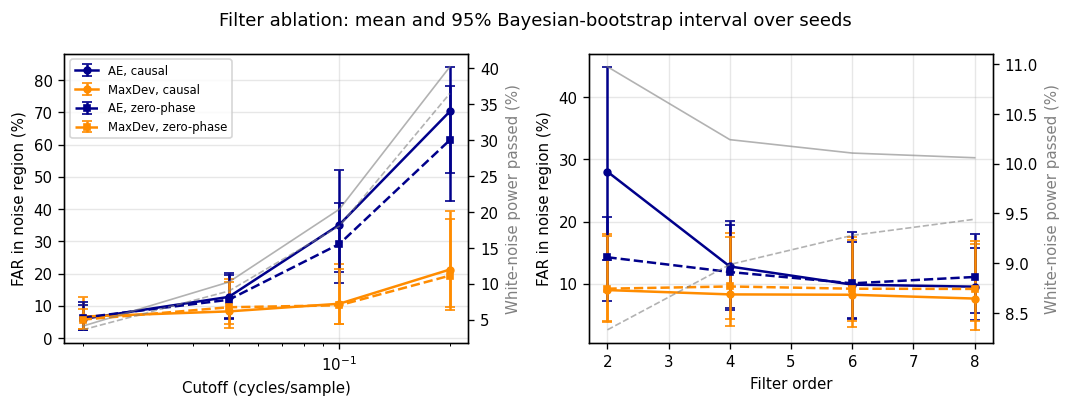

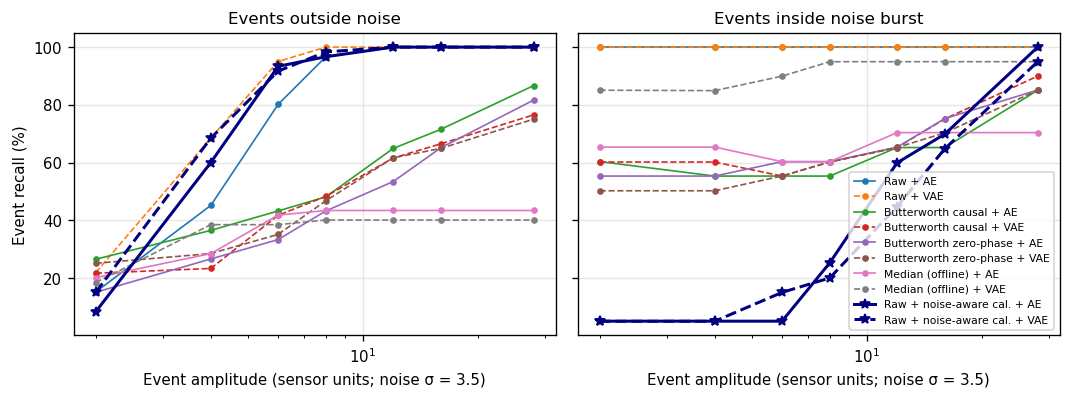

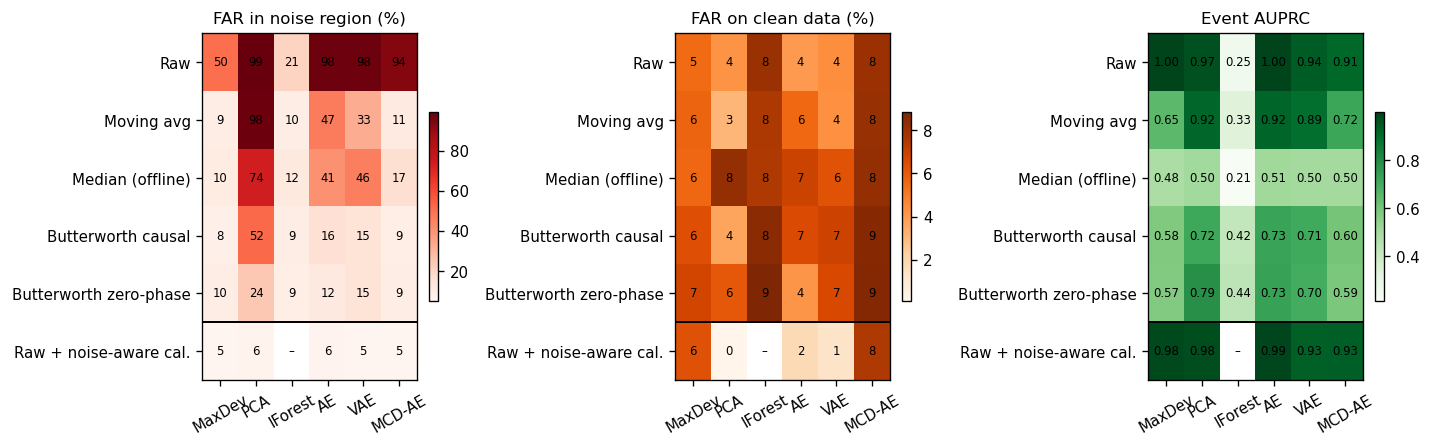

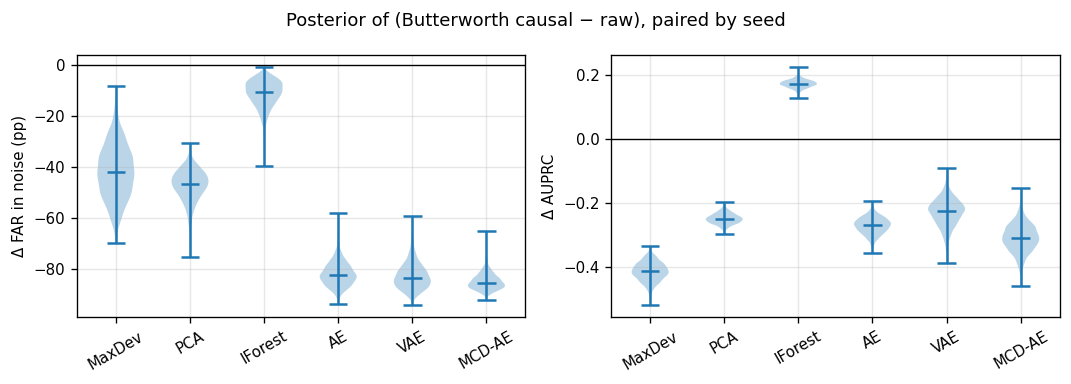

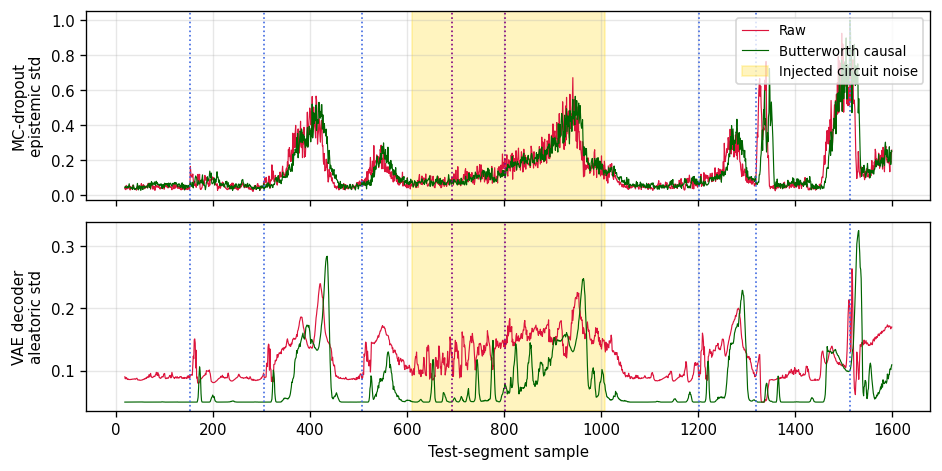

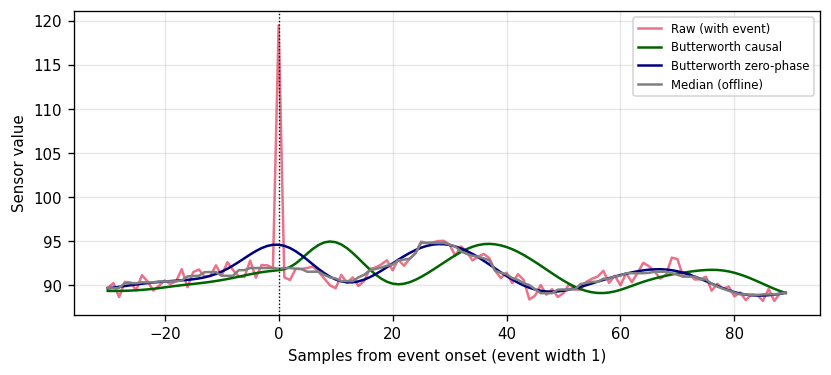

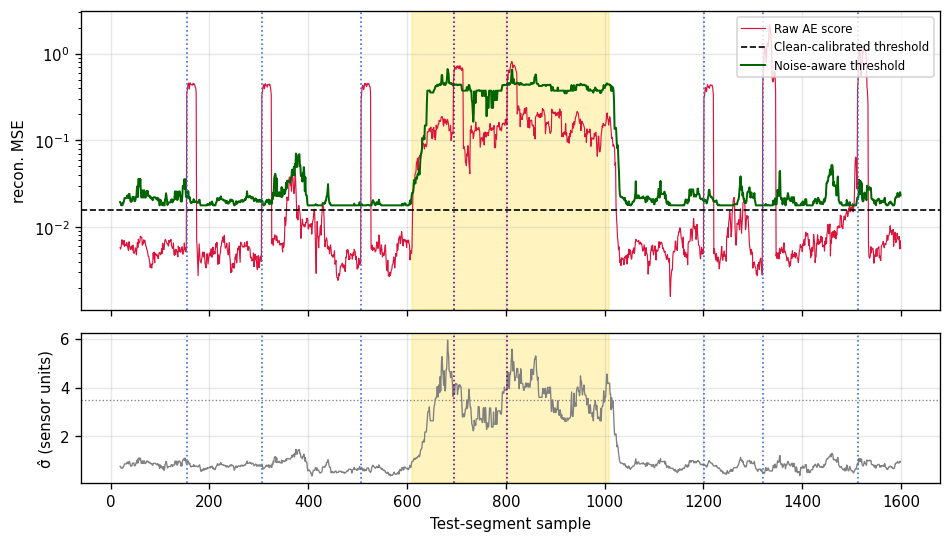


All outputs in ./results_v3/ (884s)


In [3]:
import json
import os
import time
import urllib.request
import warnings
from contextlib import contextmanager
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal as sps
import torch
import torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

# 0. Configuration
QUICK = os.environ.get("QUICK", "0") == "1"

CFG = dict(
    data_url="https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/"
             "machine_temperature_system_failure.csv",
    labels_url="https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_windows.json",
    nab_key="realKnownCause/machine_temperature_system_failure.csv",
    local_csv="machine_temperature_system_failure.csv",
    local_labels="combined_windows.json",
    sample_period_min=5,          # native NAB sampling period
    label_margin=288,             # keep 1 day (288 samples) away from labelled anomalies
    # temporal split (samples): train | gap | calibration | gap | test
    window=20,
    n_train=2000, n_cal=600, n_test=1600,
    # fault injection (raw sensor units, same scale as v1)
    noise_sigma=3.5, noise_len=400,
    n_events_clean=6, n_events_in_noise=2,
    event_widths=(1, 3, 8),
    main_amp=28.0,
    amp_sweep=(2.0, 4.0, 6.0, 8.0, 12.0, 16.0, 28.0),
    threshold_pct=97.5,
    # filters (cutoff in cycles/sample; Nyquist = 0.5)
    base_cutoff=0.05, base_order=4,
    cutoffs=(0.02, 0.05, 0.1, 0.2), orders=(2, 4, 6, 8),
    median_kernel=9,
    spread_cap=200,
    # models
    ae_hidden=12, ae_latent=6,
    vae_hidden=16, vae_latent=4, vae_mc=16,
    mcd_p=0.1, mcd_T=20,
    epochs=20 if QUICK else 60, batch=64, lr=5e-3,
    n_seeds=2 if QUICK else 10,
    n_boot=4000,
    # noise-aware calibration (no filtering; threshold depends on local noise level)
    na_est_len=32,                # trailing samples of the robust noise estimate (fixed a priori)
    na_sigma_max=6.0,             # assumed upper bound on hardware noise (raw units)
    na_levels=13,                 # synthetic white-noise levels in [0, na_sigma_max]
    na_bins=12,                   # Mondrian bins over sigma_hat
    na_scorers=("MaxDev", "PCA", "AE", "VAE", "MCD-AE"),
    na_est_len_grid=(8, 16, 32, 64, 128),
    na_sigma_max_grid=(2.0, 3.5, 6.0, 10.0),
    # test-time noise that calibration never sees (same variance as the white burst)
    mismatch_kinds=("student_t", "ar1"),
    t_df=3, ar_phi=0.8,
    out_dir="results_v3",
)

PREPROCS = ["raw", "moving_avg", "median", "butter_causal", "butter_zerophase"]
NA, ORACLE = "raw_noise_aware", "raw_oracle_sigma"
METHODS = PREPROCS + [NA, ORACLE]          # rows of the result tables
SCORERS = ["MaxDev", "PCA", "IForest", "AE", "VAE", "MCD-AE"]
TORCH_SCORERS = {"AE", "VAE", "MCD-AE"}

os.makedirs(os.path.join(CFG["out_dir"], "figures"), exist_ok=True)
plt.rcParams.update({"font.size": 9, "axes.titlesize": 10, "legend.fontsize": 8,
                     "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight"})


def savefig(fig, name):
    fig.savefig(os.path.join(CFG["out_dir"], "figures", name))
    plt.show()
    plt.close(fig)


# 1. Data: real NAB segments that are free of labelled anomalies
def _read_text(local, url):
    if os.path.exists(local):
        with open(local) as f:
            return f.read()
    with urllib.request.urlopen(url, timeout=30) as r:
        txt = r.read().decode()
    with open(local, "w") as f:
        f.write(txt)
    return txt


def load_nab(cfg):
    """Return the raw series and a list of (start, end) runs that are safe to sample."""
    from io import StringIO
    df = pd.read_csv(StringIO(_read_text(cfg["local_csv"], cfg["data_url"])),
                     parse_dates=["timestamp"])
    windows = json.loads(_read_text(cfg["local_labels"], cfg["labels_url"]))[cfg["nab_key"]]

    bad = np.zeros(len(df), bool)
    for s, e in windows:
        bad |= ((df.timestamp >= pd.Timestamp(s)) & (df.timestamp <= pd.Timestamp(e))).values
    # widen every labelled window by the safety margin
    bad = np.convolve(bad.astype(int), np.ones(2 * cfg["label_margin"] + 1), "same") > 0
    # break runs at irregular timestamps
    dt = df.timestamp.diff().dt.total_seconds().values
    breaks = set(np.where(dt != cfg["sample_period_min"] * 60)[0][1:])

    runs, start = [], None
    for i in range(len(df) + 1):
        ok = i < len(df) and not bad[i] and i not in breaks
        if ok and start is None:
            start = i
        elif not ok and start is not None:
            runs.append((start, i))
            start = i if (i < len(df) and not bad[i]) else None
    print(f"NAB series: {len(df)} samples, labelled windows: {len(windows)}")
    print(f"Anomaly-free runs (start, end): {runs}")
    return df.value.values.astype(float), runs


def seg_len(cfg):
    return cfg["n_train"] + cfg["window"] + cfg["n_cal"] + cfg["window"] + cfg["n_test"]


def pick_segment(series, runs, rng, cfg):
    L = seg_len(cfg)
    usable = [(s, e) for s, e in runs if e - s >= L]
    if not usable:
        raise RuntimeError("No anomaly-free run is long enough for the requested split.")
    s, e = usable[rng.integers(len(usable))]
    start = int(rng.integers(s, e - L + 1))
    return series[start:start + L].copy(), start


# 2. Fault-injection layout (only inside the test segment)
@dataclass
class Layout:
    n: int
    train: tuple
    cal: tuple
    test: tuple
    noise: tuple            # (start, end) inclusive
    noise_vec: np.ndarray   # unit-variance realisation
    events: list            # [(start, end_inclusive, in_noise)]


def make_layout(rng, cfg):
    W = cfg["window"]
    tr = (0, cfg["n_train"])
    ca = (tr[1] + W, tr[1] + W + cfg["n_cal"])
    te = (ca[1] + W, ca[1] + W + cfg["n_test"])
    nl = cfg["noise_len"]
    ns = int(rng.integers(te[0] + 150, te[1] - nl - 150))
    noise = (ns, ns + nl - 1)

    def place(k, lo, hi, forbid, spacing=80):
        out = []
        for _ in range(10000):
            if len(out) == k:
                break
            w = int(rng.choice(cfg["event_widths"]))
            a = int(rng.integers(lo, hi - w))
            b = a + w - 1
            if any(a <= f1 and b >= f0 for f0, f1 in forbid):
                continue
            if any(abs(a - o[0]) < spacing for o in out):
                continue
            out.append((a, b))
        if len(out) < k:
            raise RuntimeError("Could not place events; reduce their number.")
        return out

    clean_ev = place(cfg["n_events_clean"], te[0] + 40, te[1] - 40,
                     forbid=[(noise[0] - 60, noise[1] + 60)])
    noise_ev = place(cfg["n_events_in_noise"], noise[0] + 3 * W, noise[1] - 3 * W, forbid=[])
    events = sorted([(a, b, False) for a, b in clean_ev] + [(a, b, True) for a, b in noise_ev])
    return Layout(seg_len(cfg), tr, ca, te, noise, rng.normal(0, 1, nl), events)


def inject(clean, lay, amp, sigma, noise_vec=None):
    """noise_vec: unit-variance burst realisation; defaults to the white one in the layout."""
    vec = lay.noise_vec if noise_vec is None else noise_vec
    x = clean.copy()
    x[lay.noise[0]:lay.noise[1] + 1] += sigma * vec
    for a, b, _ in lay.events:
        x[a:b + 1] += amp
    return x


def mismatch_noise(kind, n, rng, cfg):
    """Unit-variance burst noise of a kind that calibration never sees."""
    if kind == "student_t":                       # heavy-tailed
        df = cfg["t_df"]
        return rng.standard_t(df, n) / np.sqrt(df / (df - 2))
    if kind == "ar1":                             # low-frequency
        phi, e = cfg["ar_phi"], rng.normal(0, 1, n)
        v = np.empty(n)
        v[0] = e[0]
        for t in range(1, n):
            v[t] = phi * v[t - 1] + np.sqrt(1 - phi ** 2) * e[t]
        return v
    raise ValueError(kind)


# 3. Pre-processing (signal side)
def butter_sos(fc, order):
    return sps.butter(order, fc / 0.5, btype="low", output="sos")


def causal_butter(x, sos):
    y, _ = sps.sosfilt(sos, x, zi=sps.sosfilt_zi(sos) * x[0])
    return y


def zerophase_butter(x, sos):
    return sps.sosfiltfilt(sos, x)


def moving_average(x, L):
    return np.convolve(np.r_[np.full(L - 1, x[0]), x], np.ones(L) / L, "valid")


def make_preproc(name, fc=None, order=None, cfg=CFG):
    fc = cfg["base_cutoff"] if fc is None else fc
    order = cfg["base_order"] if order is None else order
    if name == "raw":
        return lambda x: x
    if name == "butter_causal":
        sos = butter_sos(fc, order)
        return lambda x: causal_butter(x, sos)
    if name == "butter_zerophase":
        sos = butter_sos(fc, order)
        return lambda x: zerophase_butter(x, sos)
    if name == "moving_avg":       # length chosen so its -3 dB point matches fc
        L = max(2, int(round(0.443 / fc)))
        return lambda x: moving_average(x, L)
    if name == "median":           # offline, non-linear negative control
        return lambda x: sps.medfilt(x, cfg["median_kernel"])
    raise ValueError(name)


def impulse_spread(fn, cap):
    """How far a 1-sample event is smeared to the left/right (5% of peak criterion)."""
    n, c = 2001, 1000
    d = np.zeros(n)
    d[c] = 1.0
    r = np.abs(fn(d))
    if r.max() < 1e-9:
        return 0, 0
    idx = np.where(r > 0.05 * r.max())[0]
    return int(min(c - idx.min(), cap)), int(min(idx.max() - c, cap))


def filter_properties(fc, order):
    """Exact white-noise power gain (Parseval), surviving impulse peak and delay."""
    sos = butter_sos(fc, order)
    n, c = 4001, 2000
    d = np.zeros(n)
    d[c] = 1.0
    h_c = causal_butter(d, sos)[c:]                 # causal impulse response
    h_z = zerophase_butter(d, sos)                  # zero-phase impulse response
    return dict(
        cutoff=fc, order=order,
        noise_power_causal=float(np.sum(h_c ** 2)),
        noise_power_zerophase=float(np.sum(h_z ** 2)),
        impulse_peak_causal=float(np.abs(h_c).max()),
        impulse_peak_zerophase=float(np.abs(h_z).max()),
        delay_samples_causal=int(np.argmax(np.abs(h_c))),
    )


# 4. Detectors
class DenseAE(nn.Module):
    """20-12-6-12-20 dense autoencoder (674 parameters when W=20); optional dropout."""

    def __init__(self, W, hidden, latent, p=0.0):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(W, hidden), nn.ReLU(), nn.Dropout(p),
                                     nn.Linear(hidden, latent))
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Dropout(p),
                                     nn.Linear(hidden, W))

    def forward(self, x):
        return self.decoder(self.encoder(x))


class GaussVAE(nn.Module):
    """VAE with diagonal Gaussian posterior and heteroscedastic Gaussian decoder."""

    def __init__(self, W, hidden, latent):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(W, hidden), nn.ReLU())
        self.mu = nn.Linear(hidden, latent)
        self.lv = nn.Linear(hidden, latent)
        self.dec = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU())
        self.out_mu = nn.Linear(hidden, W)
        self.out_lv = nn.Linear(hidden, W)

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.lv(h).clamp(-8, 4)

    def decode(self, z):
        h = self.dec(z)
        return self.out_mu(h), self.out_lv(h).clamp(-6, 4)

    def elbo_loss(self, x):
        mu, lv = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        xm, xlv = self.decode(z)
        nll = 0.5 * (((x - xm) ** 2) / torch.exp(xlv) + xlv + np.log(2 * np.pi)).sum(1)
        kl = -0.5 * (1 + lv - mu ** 2 - torch.exp(lv)).sum(1)
        return (nll + kl).mean()


def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


def train_torch(model, X, loss_fn, seed, cfg):
    torch.manual_seed(seed)
    Xt = torch.tensor(X, dtype=torch.float32)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    g = torch.Generator().manual_seed(seed)
    model.train()
    for _ in range(cfg["epochs"]):
        perm = torch.randperm(len(Xt), generator=g)
        for i in range(0, len(Xt), cfg["batch"]):
            xb = Xt[perm[i:i + cfg["batch"]]]
            loss = loss_fn(model, xb)
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model


class Detector:
    """Wraps a fitted model: .score(X) -> anomaly score per window (higher = worse)."""

    def __init__(self, name, Xtr, seed, cfg):
        self.name, self.cfg, self.seed, self.aux = name, cfg, seed, {}
        W = Xtr.shape[1]
        if name == "MaxDev":
            self.model = None
        elif name == "PCA":
            self.model = PCA(cfg["ae_latent"]).fit(Xtr)
        elif name == "IForest":
            self.model = IsolationForest(n_estimators=200, random_state=seed).fit(Xtr)
        elif name == "AE":
            self.model = train_torch(DenseAE(W, cfg["ae_hidden"], cfg["ae_latent"]), Xtr,
                                     lambda m, x: ((m(x) - x) ** 2).mean(), seed, cfg)
        elif name == "MCD-AE":
            self.model = train_torch(DenseAE(W, cfg["ae_hidden"], cfg["ae_latent"], cfg["mcd_p"]),
                                     Xtr, lambda m, x: ((m(x) - x) ** 2).mean(), seed, cfg)
            mu, _ = self._mc(Xtr)
            self.sigma_a2 = float(np.mean((Xtr - mu) ** 2))   # aleatoric variance
        elif name == "VAE":
            self.model = train_torch(GaussVAE(W, cfg["vae_hidden"], cfg["vae_latent"]), Xtr,
                                     lambda m, x: m.elbo_loss(x), seed, cfg)
        else:
            raise ValueError(name)

    @torch.no_grad()
    def _mc(self, X):
        torch.manual_seed(self.seed + 7)
        self.model.train()                                     # keep dropout active
        Xt = torch.tensor(X, dtype=torch.float32)
        S = torch.stack([self.model(Xt) for _ in range(self.cfg["mcd_T"])]).numpy()
        return S.mean(0), S.var(0)

    @torch.no_grad()
    def score(self, X):
        n = self.name
        if n == "MaxDev":
            return np.max(np.abs(X - np.median(X, axis=1, keepdims=True)), axis=1)
        if n == "PCA":
            R = self.model.inverse_transform(self.model.transform(X))
            return np.mean((X - R) ** 2, axis=1)
        if n == "IForest":
            return -self.model.score_samples(X)
        Xt = torch.tensor(X, dtype=torch.float32)
        if n == "AE":
            self.model.eval()
            return ((self.model(Xt) - Xt) ** 2).mean(1).numpy()
        if n == "MCD-AE":
            mu, var_ep = self._mc(X)
            v = var_ep + self.sigma_a2
            self.aux["epistemic_std"] = np.sqrt(var_ep).mean(1)
            return np.mean(0.5 * ((X - mu) ** 2 / v + np.log(v)), axis=1)
        if n == "VAE":
            torch.manual_seed(self.seed + 11)
            self.model.eval()
            mu, lv = self.model.encode(Xt)
            lps, sig = [], []
            for _ in range(self.cfg["vae_mc"]):
                z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
                xm, xlv = self.model.decode(z)
                lps.append(-0.5 * (((Xt - xm) ** 2) / torch.exp(xlv) + xlv
                                   + np.log(2 * np.pi)).sum(1))
                sig.append(torch.exp(0.5 * xlv).mean(1))
            lp = torch.logsumexp(torch.stack(lps), 0) - np.log(len(lps))
            self.aux["aleatoric_std"] = torch.stack(sig).mean(0).numpy()
            return (-lp).numpy()
        raise ValueError(n)


# 4b. Noise-aware threshold calibration (alternative to pre-filtering)
@contextmanager
def preserve_torch_rng():
    """Extra scoring must not shift PyTorch's global generator, so that every network
    initialisation (and hence every number of the filtering study) is unchanged."""
    state = torch.get_rng_state()
    try:
        yield
    finally:
        torch.set_rng_state(state)


def local_sigma(x, M):
    """Causal noise level at every sample: 1.4826 * MAD of the last M first differences / sqrt(2).
    Dense noise moves the median; a sparse event changes only 2 of the M differences."""
    d = np.diff(x, prepend=x[0])
    d = np.r_[np.full(M - 1, d[1]), d]
    V = sliding_window_view(d, M)                        # row t = d[t-M+1 .. t]
    med = np.median(V, axis=1, keepdims=True)
    return 1.4826 * np.median(np.abs(V - med), axis=1) / np.sqrt(2)


def at_window_end(v, seg, W):
    """Per-sample series evaluated at the alarm time (window end) of each window in seg."""
    return v[np.arange(seg[0], seg[1] - W + 1) + W - 1]


class NoiseAwareThreshold:
    """Mondrian split-conformal threshold tau(sigma_hat): one finite-sample conformal
    quantile per sigma_hat bin, made non-decreasing and interpolated linearly."""

    def __init__(self, z, s, alpha, n_bins):
        uniq = np.unique(z)
        if len(uniq) <= n_bins:                           # discrete levels (oracle)
            edges = np.r_[uniq, np.inf]
        else:
            edges = np.unique(np.quantile(z, np.linspace(0, 1, n_bins + 1)))
            edges[-1] = np.inf
        centres, taus = [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            m = (z >= lo) & (z < hi)
            n = int(m.sum())
            if n == 0:
                continue
            k = int(np.ceil((n + 1) * (1 - alpha)))
            taus.append(np.inf if k > n else np.sort(s[m])[k - 1])
            centres.append(np.median(z[m]))
        self.centres = np.asarray(centres)
        self.taus = np.maximum.accumulate(np.asarray(taus))

    def __call__(self, z):
        return np.interp(z, self.centres, self.taus)


def calibrate_noise_aware(det, clean, lay, mu, sd, seed, cfg, sigma_max=None, est_len=None,
                          oracle=False):
    """Clean calibration part + synthetic white noise at known levels -> tau(.).
    The noise is added to the whole clean segment only so that the trailing estimator has
    context; scores come from calibration windows only. No test data is used."""
    W = cfg["window"]
    sigma_max = cfg["na_sigma_max"] if sigma_max is None else sigma_max
    est_len = cfg["na_est_len"] if est_len is None else est_len
    rng = np.random.default_rng(20_000 + seed)
    zs, ss = [], []
    for sig in np.linspace(0.0, sigma_max, cfg["na_levels"]):
        xs = (clean + sig * rng.normal(0, 1, len(clean)) - mu) / sd
        X = window_sets(xs, cfg)[idx_range(lay.cal, W)]
        ss.append(det.score(X))
        zs.append(np.full(len(X), sig / sd) if oracle
                  else at_window_end(local_sigma(xs, est_len), lay.cal, W))
    alpha = 1 - cfg["threshold_pct"] / 100
    return NoiseAwareThreshold(np.concatenate(zs), np.concatenate(ss), alpha, cfg["na_bins"])


def oracle_sigma_test(lay, sigma, sd, W):
    """True (standardised) noise std of each test window: sigma if it touches the burst."""
    starts = np.arange(lay.test[0], lay.test[1] - W + 1)
    touch = (starts + W - 1 >= lay.noise[0]) & (starts <= lay.noise[1])
    return np.where(touch, sigma / sd, 0.0)


# 5. Evaluation
def evaluate(s, tau, lay, spread, cfg):
    """s: scores of the test windows (window i covers samples [i, i+W)).
    tau: scalar threshold (use s = margin and tau = 0 for a noise-aware threshold)."""
    W = cfg["window"]
    win = np.arange(lay.test[0], lay.test[1] - W + 1)
    alarm = s > tau
    L, R = spread

    def overlap(a, b):
        a, b = max(0, a - L), min(lay.n - 1, b + R)
        return (win + W - 1 >= a) & (win <= b)

    per_ev = [overlap(a, b) for a, b, _ in lay.events]
    ev_win = np.any(per_ev, axis=0)
    nz_win = overlap(*lay.noise) & ~ev_win
    cl_win = ~ev_win & ~nz_win

    det = np.array([alarm[m].any() for m in per_ev])
    in_noise = np.array([e[2] for e in lay.events])
    lat = [(win[m][alarm[m]][0] + W - 1) - lay.events[k][0]
           for k, m in enumerate(per_ev) if det[k] and not in_noise[k]]
    # share of noise false alarms raised in the first na_est_len samples of the burst
    onset = nz_win & (win + W - 1 < lay.noise[0] + cfg["na_est_len"])
    n_fa = alarm[nz_win].sum()

    out = dict(
        far_noise=100 * alarm[nz_win].mean(),
        far_clean=100 * alarm[cl_win].mean(),
        recall=100 * det[~in_noise].mean(),
        recall_in_noise=100 * det[in_noise].mean() if in_noise.any() else np.nan,
        latency=float(np.median(lat)) if lat else np.nan,
        auprc=average_precision_score(ev_win, s),
        n_noise_windows=int(nz_win.sum()),
        n_noise_fa=int(n_fa),
        n_noise_fa_onset=int(alarm[onset].sum()),
    )
    try:
        m = ev_win | nz_win
        out["auroc_ev_vs_noise"] = roc_auc_score(ev_win[m], s[m])
    except ValueError:
        out["auroc_ev_vs_noise"] = np.nan
    return out


# 6. Bayesian evaluation of results across seeds
def bayes_boot(v, rng, n):
    """Posterior draws of the mean under the Bayesian bootstrap (Dirichlet(1,...,1))."""
    v = np.asarray(v, float)
    v = v[~np.isnan(v)]
    if len(v) == 0:
        return np.full(n, np.nan)
    return rng.dirichlet(np.ones(len(v)), n) @ v


def summarise(df, by, metrics, cfg):
    rows = []
    for key, g in df.groupby(by, sort=False):
        rng = np.random.default_rng(0)       # same draws per group: values do not depend on grouping
        r = dict(zip(by, key if isinstance(key, tuple) else (key,)))
        for m in metrics:
            post = bayes_boot(g[m].values, rng, cfg["n_boot"])
            r[m] = np.nanmean(post)
            r[m + "_lo"], r[m + "_hi"] = np.nanpercentile(post, [2.5, 97.5])
        rows.append(r)
    return pd.DataFrame(rows)


def fmt_table(summ, by, metrics, digits=1):
    t = summ[by].copy()
    for m in metrics:
        d = 3 if m.startswith("au") else digits
        t[m] = [f"{a:.{d}f} [{lo:.{d}f}, {hi:.{d}f}]"
                for a, lo, hi in zip(summ[m], summ[m + "_lo"], summ[m + "_hi"])]
    return t


def paired_posterior(df, metric, a, b, cfg, key="preproc"):
    """Posterior of mean(metric[a] - metric[b]) paired by seed, per scorer."""
    rng = np.random.default_rng(1)
    out = {}
    for sc, g in df.groupby("scorer", sort=False):
        A = g[g[key] == a].set_index("seed")[metric]
        B = g[g[key] == b].set_index("seed")[metric]
        d = (A - B).dropna().values
        out[sc] = bayes_boot(d, rng, cfg["n_boot"])
    return out


def print_paired(df, metrics, a, b, scorers, cfg, title):
    print(f"\n{title}")
    for m in metrics:
        post = paired_posterior(df, m, a, b, cfg)
        for sc in scorers:
            p = post.get(sc)
            if p is None or np.isnan(p).all():
                continue
            print(f"  {sc:8s} Δ{m:16s} {np.mean(p):+8.2f} "
                  f"[{np.percentile(p, 2.5):+.2f}, {np.percentile(p, 97.5):+.2f}]  "
                  f"P(Δ<0)={np.mean(p < 0):.2f}  P(Δ>0)={np.mean(p > 0):.2f}")


# 7. Experiments
def window_sets(x, cfg):
    W = cfg["window"]
    return sliding_window_view(x, W)                     # (n - W + 1, W): no off-by-one


def idx_range(seg, W):
    return slice(seg[0], seg[1] - W + 1)


def run_config(clean, dirty_by_amp, lay, pre, scorers, seed, cfg, keep_trace=False,
               mismatch=None, noise_aware=False):
    """mismatch: {kind: dirty signal at main_amp} evaluated with every method.
    noise_aware: also evaluate the noise-aware and oracle-sigma thresholds (raw input only).
    Everything beyond the original filtering study runs inside preserve_torch_rng()."""
    W = cfg["window"]
    xc = pre(clean)
    mu, sd = xc[:lay.train[1]].mean(), xc[:lay.train[1]].std()
    Wc = window_sets((xc - mu) / sd, cfg)
    Xtr, Xcal = Wc[idx_range(lay.train, W)], Wc[idx_range(lay.cal, W)]
    xte = {a: (pre(d) - mu) / sd for a, d in dirty_by_amp.items()}
    Xte = {a: window_sets(x, cfg)[idx_range(lay.test, W)] for a, x in xte.items()}
    spread = impulse_spread(pre, cfg["spread_cap"])
    mismatch = mismatch or {}

    results, traces, na_ablation = [], {}, []
    for sname in scorers:
        det = Detector(sname, Xtr, seed, cfg)
        tau = float(np.percentile(det.score(Xcal), cfg["threshold_pct"]))
        for amp, X in Xte.items():
            s = det.score(X)
            m = evaluate(s, tau, lay, spread, cfg)
            results.append(dict(scorer=sname, amp=amp, noise_kind="white", tau=tau, **m))
            if keep_trace and amp == cfg["main_amp"]:
                traces[sname] = dict(score=s, tau=tau, aux=dict(det.aux))

        with preserve_torch_rng():
            # 1) mismatched test noise, clean-data threshold
            mm_x = {k: (pre(d) - mu) / sd for k, d in mismatch.items()}
            for kind, x in mm_x.items():
                s = det.score(window_sets(x, cfg)[idx_range(lay.test, W)])
                results.append(dict(scorer=sname, amp=cfg["main_amp"], noise_kind=kind,
                                    tau=tau, **evaluate(s, tau, lay, spread, cfg)))
            if not (noise_aware and sname in cfg["na_scorers"]):
                continue
            # 2) noise-aware and oracle-sigma thresholds on the raw signal
            f_na = calibrate_noise_aware(det, clean, lay, mu, sd, seed, cfg)
            f_or = calibrate_noise_aware(det, clean, lay, mu, sd, seed, cfg, oracle=True)
            z_or = oracle_sigma_test(lay, cfg["noise_sigma"], sd, W)
            tests = [(a, "white", x) for a, x in xte.items()] + \
                    [(cfg["main_amp"], k, x) for k, x in mm_x.items()]
            for amp, kind, x in tests:
                s = det.score(window_sets(x, cfg)[idx_range(lay.test, W)])
                z = at_window_end(local_sigma(x, cfg["na_est_len"]), lay.test, W)
                tau_t = f_na(z)
                for name, margin in [(NA, s - tau_t), (ORACLE, s - f_or(z_or))]:
                    results.append(dict(preproc=name, scorer=sname, amp=amp, noise_kind=kind,
                                        tau=np.nan, **evaluate(margin, 0.0, lay, spread, cfg)))
                if keep_trace and kind == "white" and amp == cfg["main_amp"]:
                    traces[sname].update(tau_na=tau_t, sigma_hat=z * sd)
            # 3) ablation of the estimator length and the assumed noise bound (AE only)
            if sname == "AE":
                x = xte[cfg["main_amp"]]
                s = det.score(window_sets(x, cfg)[idx_range(lay.test, W)])
                for M in cfg["na_est_len_grid"]:
                    z = at_window_end(local_sigma(x, M), lay.test, W)
                    for smax in cfg["na_sigma_max_grid"]:
                        f = calibrate_noise_aware(det, clean, lay, mu, sd, seed, cfg,
                                                  sigma_max=smax, est_len=M)
                        na_ablation.append(dict(seed=seed, est_len=M, sigma_max=smax,
                                                **evaluate(s - f(z), 0.0, lay, spread, cfg)))
    return results, traces, na_ablation


def main_experiment(series, runs, cfg):
    rows, traces, layouts, na_abl = [], {}, {}, []
    for seed in range(cfg["n_seeds"]):
        t0 = time.time()
        rng = np.random.default_rng(seed)
        clean, start = pick_segment(series, runs, rng, cfg)
        lay = make_layout(rng, cfg)
        dirty = {a: inject(clean, lay, a, cfg["noise_sigma"]) for a in cfg["amp_sweep"]}
        rng_mm = np.random.default_rng(10_000 + seed)       # independent of the layout stream
        mismatch = {k: inject(clean, lay, cfg["main_amp"], cfg["noise_sigma"],
                              mismatch_noise(k, len(lay.noise_vec), rng_mm, cfg))
                    for k in cfg["mismatch_kinds"]}
        layouts[seed] = (clean, dirty[cfg["main_amp"]], lay, start)
        for p in PREPROCS:
            res, tr, abl = run_config(clean, dirty, lay, make_preproc(p, cfg=cfg), SCORERS, seed,
                                      cfg, keep_trace=(seed == 0), mismatch=mismatch,
                                      noise_aware=(p == "raw"))
            for r in res:
                rows.append({**dict(seed=seed, preproc=p, segment_start=start), **r})
            na_abl += abl
            if seed == 0:
                traces[p] = tr
        print(f"  seed {seed}: segment start {start}, done in {time.time() - t0:.1f}s")
    return pd.DataFrame(rows), traces, layouts, pd.DataFrame(na_abl)


def ablation_experiment(series, runs, cfg):
    configs = [(fc, cfg["base_order"]) for fc in cfg["cutoffs"]] + \
              [(cfg["base_cutoff"], o) for o in cfg["orders"] if o != cfg["base_order"]]
    rows = []
    for seed in range(cfg["n_seeds"]):
        rng = np.random.default_rng(seed)
        clean, _ = pick_segment(series, runs, rng, cfg)
        lay = make_layout(rng, cfg)
        dirty = {cfg["main_amp"]: inject(clean, lay, cfg["main_amp"], cfg["noise_sigma"])}
        for mode in ["butter_causal", "butter_zerophase"]:
            for fc, o in configs:
                res, _, _ = run_config(clean, dirty, lay, make_preproc(mode, fc, o, cfg),
                                       ["MaxDev", "AE"], seed, cfg)
                for r in res:
                    rows.append(dict(seed=seed, mode=mode, cutoff=fc, order=o, **r))
    return pd.DataFrame(rows)


# 8. Figures
PRE_LABEL = {"raw": "Raw", "moving_avg": "Moving avg", "median": "Median (offline)",
             "butter_causal": "Butterworth causal", "butter_zerophase": "Butterworth zero-phase",
             NA: "Raw + noise-aware cal.", ORACLE: "Raw + oracle-σ cal. (ref.)"}


def shade_layout(ax, lay, off):
    ax.axvspan(lay.noise[0] - off, lay.noise[1] - off, color="gold", alpha=0.25,
               label="Injected circuit noise")
    for a, b, inn in lay.events:
        ax.axvline(a - off, color="royalblue" if not inn else "purple", ls=":", lw=1)


def fig_scores(traces, layouts, cfg):
    _, _, lay, _ = layouts[0]
    W = cfg["window"]
    x = np.arange(lay.test[0], lay.test[1] - W + 1) + W - 1   # alarm time = window end
    rows = [("raw", "AE"), ("butter_causal", "AE"), ("butter_zerophase", "AE"),
            ("butter_causal", "VAE")]
    fig, axes = plt.subplots(len(rows), 1, figsize=(8, 8), sharex=True)
    for ax, (p, sc) in zip(axes, rows):
        t = traces[p][sc]
        y = t["score"] - min(t["score"].min(), t["tau"]) + 1e-6 if sc == "VAE" else t["score"]
        tau = t["tau"] - min(t["score"].min(), t["tau"]) + 1e-6 if sc == "VAE" else t["tau"]
        ax.semilogy(x - lay.test[0], y, lw=0.7, color="crimson" if p == "raw" else "darkgreen")
        ax.axhline(tau, color="k", ls="--", lw=1, label="Threshold (calibration 97.5%)")
        shade_layout(ax, lay, lay.test[0])
        ax.set_title(f"{PRE_LABEL[p]} + {sc}")
        ax.set_ylabel("score (VAE: shifted NLL)" if sc == "VAE" else "recon. MSE")
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Test-segment sample (5 min); dotted: events (blue clean, purple in noise)")
    fig.suptitle("Anomaly scores on the test segment (seed 0)", fontweight="bold")
    fig.tight_layout()
    savefig(fig, "fig1_scores.png")


def fig_filter_response(cfg):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    for ax, items, title in [
        (axes[0], [(fc, cfg["base_order"]) for fc in cfg["cutoffs"]], "Cutoff sweep (4th order)"),
        (axes[1], [(cfg["base_cutoff"], o) for o in cfg["orders"]], "Order sweep (0.05 cyc/sample)"),
    ]:
        for fc, o in items:
            w, h = sps.sosfreqz(butter_sos(fc, o), worN=2048, fs=1.0)
            lab = f"{fc}" if ax is axes[0] else f"order {o}"
            line, = ax.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=lab)
            ax.plot(w, 40 * np.log10(np.abs(h) + 1e-12), ls="--", color=line.get_color(), lw=0.8)
        ax.axvline(cfg["base_cutoff"], color="gray", ls=":")
        ax.set_ylim(-80, 5)
        ax.set_xlabel("Frequency (cycles/sample; ×12 = cycles/hour)")
        ax.set_ylabel("Magnitude (dB)")
        ax.set_title(title)
        ax.legend(title="solid: causal, dashed: zero-phase")
        ax.grid(alpha=0.3)
    fig.tight_layout()
    savefig(fig, "fig2_filter_response.png")


def fig_ablation(abl_sum, props, cfg):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
    base_o, base_fc = cfg["base_order"], cfg["base_cutoff"]
    for ax, var, fixed in [(axes[0], "cutoff", ("order", base_o)),
                           (axes[1], "order", ("cutoff", base_fc))]:
        ax2 = ax.twinx()
        for mode, mk in [("butter_causal", "o-"), ("butter_zerophase", "s--")]:
            for sc, col in [("AE", "darkblue"), ("MaxDev", "darkorange")]:
                g = abl_sum[(abl_sum["mode"] == mode) & (abl_sum.scorer == sc)
                            & (abl_sum[fixed[0]] == fixed[1])].sort_values(var)
                ax.errorbar(g[var], g.far_noise, yerr=[g.far_noise - g.far_noise_lo,
                                                       g.far_noise_hi - g.far_noise],
                            fmt=mk, color=col, capsize=3, ms=4,
                            label=f"{sc}, {'causal' if 'causal' in mode else 'zero-phase'}")
        pp = props[props[fixed[0]] == fixed[1]].sort_values(var)
        ax2.plot(pp[var], 100 * pp.noise_power_causal, color="gray", lw=1, alpha=0.6)
        ax2.plot(pp[var], 100 * pp.noise_power_zerophase, color="gray", lw=1, ls="--", alpha=0.6)
        ax2.set_ylabel("White-noise power passed (%)", color="gray")
        ax.set_xlabel("Cutoff (cycles/sample)" if var == "cutoff" else "Filter order")
        if var == "cutoff":
            ax.set_xscale("log")
        ax.set_ylabel("FAR in noise region (%)")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=7)
    fig.suptitle("Filter ablation: mean and 95% Bayesian-bootstrap interval over seeds")
    fig.tight_layout()
    savefig(fig, "fig3_ablation.png")


def fig_amp_sweep(summ_amp):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
    for ax, m, title in [(axes[0], "recall", "Events outside noise"),
                         (axes[1], "recall_in_noise", "Events inside noise burst")]:
        for p in ["raw", "butter_causal", "butter_zerophase", "median", NA]:
            for sc, ls in [("AE", "-"), ("VAE", "--")]:
                g = summ_amp[(summ_amp.preproc == p) & (summ_amp.scorer == sc)].sort_values("amp")
                ax.plot(g.amp, g[m], ls, marker="*" if p == NA else "o",
                        ms=6 if p == NA else 3, lw=1.8 if p == NA else 1,
                        color="navy" if p == NA else None, label=f"{PRE_LABEL[p]} + {sc}")
        ax.set_xscale("log")
        ax.set_xlabel("Event amplitude (sensor units; noise σ = 3.5)")
        ax.set_title(title)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Event recall (%)")
    axes[1].legend(fontsize=6.5)
    fig.tight_layout()
    savefig(fig, "fig4_amplitude_sweep.png")


def fig_heatmaps(summ):
    rows = PREPROCS + [NA]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, m, cmap, title in [(axes[0], "far_noise", "Reds", "FAR in noise region (%)"),
                               (axes[1], "far_clean", "Oranges", "FAR on clean data (%)"),
                               (axes[2], "auprc", "Greens", "Event AUPRC")]:
        piv = summ.pivot(index="preproc", columns="scorer", values=m).reindex(index=rows,
                                                                              columns=SCORERS)
        im = ax.imshow(np.ma.masked_invalid(piv.values), cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(SCORERS)), SCORERS, rotation=30)
        ax.set_yticks(range(len(rows)), [PRE_LABEL[p] for p in rows])
        ax.axhline(len(PREPROCS) - 0.5, color="k", lw=1.2)
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                txt = "–" if np.isnan(v) else (f"{v:.2f}" if m == "auprc" else f"{v:.0f}")
                ax.text(j, i, txt, ha="center", va="center", fontsize=7)
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.04)
    fig.tight_layout()
    savefig(fig, "fig5_main_heatmaps.png")


def fig_bayes(post_far, post_auprc):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    for ax, post, lab in [(axes[0], post_far, "Δ FAR in noise (pp)"),
                          (axes[1], post_auprc, "Δ AUPRC")]:
        names = [k for k in SCORERS if k in post and not np.isnan(post[k]).all()]
        ax.violinplot([post[k] for k in names], showmedians=True)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_xticks(range(1, len(names) + 1), names, rotation=30)
        ax.set_ylabel(lab)
        ax.grid(alpha=0.3)
    fig.suptitle("Posterior of (Butterworth causal − raw), paired by seed")
    fig.tight_layout()
    savefig(fig, "fig6_bayes_posteriors.png")


def fig_uncertainty(traces, layouts, cfg):
    _, _, lay, _ = layouts[0]
    W = cfg["window"]
    x = np.arange(lay.test[0], lay.test[1] - W + 1) + W - 1 - lay.test[0]
    fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
    for p, col in [("raw", "crimson"), ("butter_causal", "darkgreen")]:
        axes[0].plot(x, traces[p]["MCD-AE"]["aux"]["epistemic_std"], color=col, lw=0.7,
                     label=PRE_LABEL[p])
        axes[1].plot(x, traces[p]["VAE"]["aux"]["aleatoric_std"], color=col, lw=0.7,
                     label=PRE_LABEL[p])
    axes[0].set_ylabel("MC-dropout\nepistemic std")
    axes[1].set_ylabel("VAE decoder\naleatoric std")
    for ax in axes:
        shade_layout(ax, lay, lay.test[0])
        ax.grid(alpha=0.3)
    axes[0].legend(loc="upper right")
    axes[1].set_xlabel("Test-segment sample")
    fig.tight_layout()
    savefig(fig, "fig7_uncertainty.png")


def fig_waveform(layouts, cfg):
    clean, dirty, lay, _ = layouts[0]
    a, b, _ = [e for e in lay.events if not e[2]][0]
    sl = slice(a - 30, b + 90)
    t = np.arange(sl.start, sl.stop) - a
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.plot(t, dirty[sl], color="crimson", alpha=0.6, label="Raw (with event)")
    for p, col in [("butter_causal", "darkgreen"), ("butter_zerophase", "navy"),
                   ("median", "gray")]:
        ax.plot(t, make_preproc(p, cfg=cfg)(dirty)[sl], color=col, label=PRE_LABEL[p])
    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(f"Samples from event onset (event width {b - a + 1})")
    ax.set_ylabel("Sensor value")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    savefig(fig, "fig8_waveform.png")


def fig_noise_aware_trace(traces, layouts, cfg):
    _, _, lay, _ = layouts[0]
    W = cfg["window"]
    t = traces["raw"]["AE"]
    x = np.arange(lay.test[0], lay.test[1] - W + 1) + W - 1 - lay.test[0]
    fig, axes = plt.subplots(2, 1, figsize=(8, 4.6), sharex=True,
                             gridspec_kw=dict(height_ratios=[2, 1]))
    axes[0].semilogy(x, t["score"], lw=0.7, color="crimson", label="Raw AE score")
    axes[0].axhline(t["tau"], color="k", ls="--", lw=1, label="Clean-calibrated threshold")
    axes[0].semilogy(x, t["tau_na"], color="darkgreen", lw=1.2, label="Noise-aware threshold")
    axes[0].set_ylabel("recon. MSE")
    axes[0].legend(loc="upper right", fontsize=7)
    axes[1].plot(x, t["sigma_hat"], color="gray", lw=0.8)
    axes[1].axhline(cfg["noise_sigma"], color="gray", ls=":", lw=0.8)
    axes[1].set_ylabel("σ̂ (sensor units)")
    axes[1].set_xlabel("Test-segment sample")
    for ax in axes:
        shade_layout(ax, lay, lay.test[0])
        ax.grid(alpha=0.3)
    fig.tight_layout()
    savefig(fig, "fig9_noise_aware_trace.png")


# 9. Main
if __name__ == "__main__" or "get_ipython" in globals():
    t_start = time.time()
    pd.set_option("display.width", 220)
    pd.set_option("display.max_columns", 30)
    series, runs = load_nab(CFG)
    print(f"Config: {CFG['n_seeds']} seeds, {CFG['epochs']} epochs"
          f"{' (QUICK mode)' if QUICK else ''}")
    W = CFG["window"]
    print(f"Model sizes: AE {n_params(DenseAE(W, CFG['ae_hidden'], CFG['ae_latent']))}, "
          f"VAE {n_params(GaussVAE(W, CFG['vae_hidden'], CFG['vae_latent']))} parameters")

    # filter mechanism table (exact, no training)
    props = pd.DataFrame([filter_properties(fc, CFG["base_order"]) for fc in CFG["cutoffs"]] +
                         [filter_properties(CFG["base_cutoff"], o) for o in CFG["orders"]
                          if o != CFG["base_order"]])
    print("\nFilter properties (white-noise power passed, impulse peak kept, delay)")
    print(props.round(4).to_string(index=False))
    props.to_csv(os.path.join(CFG["out_dir"], "filter_properties.csv"), index=False)

    # main experiment (includes noise-aware calibration and mismatched noise)
    print("\nMain experiment")
    df, traces, layouts, na_abl = main_experiment(series, runs, CFG)
    df.to_csv(os.path.join(CFG["out_dir"], "main_runs.csv"), index=False)
    metrics = ["far_noise", "far_clean", "recall", "recall_in_noise", "auprc",
               "auroc_ev_vs_noise", "latency"]
    white = df[df.noise_kind == "white"]
    main = white[white.amp == CFG["main_amp"]]
    summ = summarise(main, ["preproc", "scorer"], metrics, CFG)
    summ["order"] = summ.preproc.map(METHODS.index)
    summ = summ.sort_values("order", kind="stable").drop(columns="order")
    summ.to_csv(os.path.join(CFG["out_dir"], "main_summary.csv"), index=False)
    print(f"\nMain results at amplitude {CFG['main_amp']}, white noise "
          "(mean [95% Bayesian-bootstrap interval] over seeds)")
    print(fmt_table(summ, ["preproc", "scorer"],
                    ["far_noise", "far_clean", "recall", "recall_in_noise", "auprc",
                     "latency"]).to_string(index=False))

    summ_amp = summarise(white, ["preproc", "scorer", "amp"],
                         ["recall", "recall_in_noise", "far_noise"], CFG)
    summ_amp.to_csv(os.path.join(CFG["out_dir"], "amplitude_sweep_summary.csv"), index=False)
    print("\nAE recall vs amplitude (outside / inside the burst)")
    ae_amp = summ_amp[(summ_amp.scorer == "AE")
                      & summ_amp.preproc.isin(["raw", "butter_causal", "butter_zerophase", NA])]
    print(ae_amp.pivot(index="amp", columns="preproc", values="recall").round(1).to_string())
    print(ae_amp.pivot(index="amp", columns="preproc",
                       values="recall_in_noise").round(1).to_string())

    # paired Bayesian comparison
    post_far = paired_posterior(main, "far_noise", "butter_causal", "raw", CFG)
    post_auprc = paired_posterior(main, "auprc", "butter_causal", "raw", CFG)
    print("\nButterworth causal vs raw, paired by seed")
    for sc in SCORERS:
        pf, pa = post_far[sc], post_auprc[sc]
        print(f"  {sc:8s} ΔFAR_noise {np.mean(pf):+6.1f} pp "
              f"[{np.percentile(pf, 2.5):+.1f}, {np.percentile(pf, 97.5):+.1f}], "
              f"P(Δ<0)={np.mean(pf < 0):.2f} | ΔAUPRC {np.mean(pa):+.3f}, "
              f"P(Δ>0)={np.mean(pa > 0):.2f}")
    post_ae = paired_posterior(main[main.preproc == "butter_causal"].assign(
        preproc=main.scorer).assign(scorer="all"), "auprc", "AE", "MaxDev", CFG)["all"]
    print(f"  Does the AE add value over a training-free detector (both causal-filtered)? "
          f"ΔAUPRC(AE − MaxDev) {np.mean(post_ae):+.3f}, P(AE better)={np.mean(post_ae > 0):.2f}")

    na_metrics = ["far_noise", "far_clean", "recall", "recall_in_noise", "auprc", "latency"]
    print_paired(main, na_metrics, NA, "butter_causal", CFG["na_scorers"], CFG,
                 f"Noise-aware (raw) minus Butterworth causal, A = {CFG['main_amp']}")
    print_paired(main, ["far_noise", "far_clean", "auprc"], NA, "raw", CFG["na_scorers"], CFG,
                 f"Noise-aware (raw) minus clean-calibrated raw, A = {CFG['main_amp']}")
    print_paired(white[white.amp == 8.0], ["far_noise", "recall", "recall_in_noise"], NA,
                 "butter_causal", ["AE"], CFG, "Noise-aware minus Butterworth causal, A = 8")
    na_main = main[main.preproc == NA]
    print(f"\nShare of noise-aware false alarms in the first {CFG['na_est_len']} burst samples: "
          + ", ".join(f"{sc} {g.n_noise_fa_onset.sum() / max(g.n_noise_fa.sum(), 1):.2f}"
                      for sc, g in na_main.groupby("scorer", sort=False)))

    # mismatched test noise (calibration only ever assumes white Gaussian)
    mm = df[df.amp == CFG["main_amp"]]
    mm_summ = summarise(mm, ["noise_kind", "preproc", "scorer"],
                        ["far_noise", "far_clean", "recall", "auprc", "latency"], CFG)
    mm_summ.to_csv(os.path.join(CFG["out_dir"], "noise_mismatch_summary.csv"), index=False)
    print("\nNoise-model mismatch (AE)")
    sel = mm_summ[(mm_summ.scorer == "AE")
                  & mm_summ.preproc.isin(["raw", "butter_causal", NA, ORACLE])]
    print(fmt_table(sel, ["noise_kind", "preproc"],
                    ["far_noise", "far_clean", "recall", "auprc", "latency"]).to_string(index=False))

    # noise-aware ablation (estimator length x assumed noise bound)
    na_abl.to_csv(os.path.join(CFG["out_dir"], "noise_aware_ablation_runs.csv"), index=False)
    na_abl_sum = summarise(na_abl, ["est_len", "sigma_max"],
                           ["far_noise", "far_clean", "recall", "recall_in_noise"], CFG)
    na_abl_sum.to_csv(os.path.join(CFG["out_dir"], "noise_aware_ablation_summary.csv"),
                      index=False)
    print("\nNoise-aware ablation (AE, white): estimator length M x assumed sigma_max")
    print(fmt_table(na_abl_sum, ["est_len", "sigma_max"],
                    ["far_noise", "far_clean", "recall", "recall_in_noise"]).to_string(index=False))

    # filter ablation
    print("\nFilter ablation (cutoff and order)")
    abl = ablation_experiment(series, runs, CFG)
    abl.to_csv(os.path.join(CFG["out_dir"], "ablation_runs.csv"), index=False)
    abl_sum = summarise(abl, ["mode", "scorer", "cutoff", "order"],
                        ["far_noise", "far_clean", "recall", "auprc", "latency"], CFG)
    abl_sum.to_csv(os.path.join(CFG["out_dir"], "ablation_summary.csv"), index=False)
    print(fmt_table(abl_sum[abl_sum.scorer == "AE"], ["mode", "cutoff", "order"],
                    ["far_noise", "far_clean", "auprc", "latency"]).to_string(index=False))

    # figures
    fig_scores(traces, layouts, CFG)
    fig_filter_response(CFG)
    fig_ablation(abl_sum, props, CFG)
    fig_amp_sweep(summ_amp)
    fig_heatmaps(summ)
    fig_bayes(post_far, post_auprc)
    fig_uncertainty(traces, layouts, CFG)
    fig_waveform(layouts, CFG)
    fig_noise_aware_trace(traces, layouts, CFG)
    print(f"\nAll outputs in ./{CFG['out_dir']}/ ({time.time() - t_start:.0f}s)")